# Neural Network Regression (MLP)

## What it does
A **Multi-Layer Perceptron (MLP)** stacks fully-connected layers with non-linear activations:
$$h^{(l)} = \sigma(W^{(l)} h^{(l-1)} + b^{(l)}), \quad \hat{y} = W^{(L)} h^{(L-1)} + b^{(L)}$$

This notebook uses **scikit-learn's MLPRegressor** — easy to configure, supports early stopping,
and integrates with the standard toolkit utilities. For larger datasets consider PyTorch.

## Key hyperparameters
| Parameter | Effect |
|---|---|
| `hidden_layer_sizes` | Network architecture e.g. `(64,)` = 1 hidden layer with 64 units |
| `alpha` | L2 weight decay — regularizes weights |
| `learning_rate_init` | Initial step size for Adam optimizer |
| `early_stopping` | Held-out 10% of training data to stop overfitting |

## When to use it
- You want a flexible non-linear model that can capture complex interactions
- Tabular panel data where GBR and RF have already been tried
- **Requires standardization** — neural networks are sensitive to feature scale

## Data format
Panel CSV/Parquet with `DATE_COL`, `ID_COL`, `TARGET_COL`; all other numeric columns are features.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,   # Required for MLPs
    # --- MLP architecture grid ---
    'HIDDEN_LAYER_SIZES': [(32,), (64,), (128,), (64, 32), (128, 64)],
    # --- Regularization grid ---
    'ALPHA_GRID':         [1e-4, 1e-3, 0.01],   # L2 weight decay
    # --- Training settings ---
    'MAX_ITER':           500,
    'LEARNING_RATE_INIT': 1e-3,
    'EARLY_STOPPING':     True,
    'VALIDATION_FRACTION':0.1,
    'N_ITER_NO_CHANGE':   20,
    'ACTIVATION':         'relu',
    'NN_RANDOM_STATE':    42,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         'results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  HIDDEN_LAYER_SIZES: [(32,), (64,), (128,), (64, 32), (128, 64)]
  ALPHA_GRID: [0.0001, 0.001, 0.01]
  MAX_ITER: 500
  LEARNING_RATE_INIT: 0.001
  EARLY_STOPPING: True
  VALIDATION_FRACTION: 0.1
  N_ITER_NO_CHANGE: 20
  ACTIVATION: relu
  NN_RANDOM_STATE: 42
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

Standardization is **required** for MLPs: weight initialization and gradient steps assume
features are on a comparable scale.

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')

y_train_mean = float(y_train.mean())
print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features standardized (fit on training data only).


Features      : 209
Train obs     : 884
Training mean : 0.007120


## Step 3 — Grid Search: Architecture × L2 Alpha

Best hyperparameters selected by **validation OOS R²** — test set never touched.
Early stopping uses an internal 10% validation split of the training data.

In [5]:
grid_results = []

total = len(CONFIG['HIDDEN_LAYER_SIZES']) * len(CONFIG['ALPHA_GRID'])
print(f'Grid size: {total} combinations')
print('=' * 70)

for layers in CONFIG['HIDDEN_LAYER_SIZES']:
    for alpha in CONFIG['ALPHA_GRID']:
        mlp = MLPRegressor(
            hidden_layer_sizes  = layers,
            activation          = CONFIG['ACTIVATION'],
            solver              = 'adam',
            alpha               = alpha,
            max_iter            = CONFIG['MAX_ITER'],
            learning_rate_init  = CONFIG['LEARNING_RATE_INIT'],
            early_stopping      = CONFIG['EARLY_STOPPING'],
            validation_fraction = CONFIG['VALIDATION_FRACTION'],
            n_iter_no_change    = CONFIG['N_ITER_NO_CHANGE'],
            random_state        = CONFIG['NN_RANDOM_STATE'],
        )
        mlp.fit(X_train, y_train)
        val_pred = mlp.predict(X_val)
        oos_r2   = compute_oos_r2(y_val.values, val_pred, y_train_mean)
        grid_results.append({
            'layers': layers, 'alpha': alpha,
            'oos_r2_val': oos_r2, 'n_iter': mlp.n_iter_, 'model': mlp,
        })
        print(f'  layers={str(layers):12s}  alpha={alpha:.5f}  '
              f'iters={mlp.n_iter_:4d}  Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: layers={best['layers']}, alpha={best['alpha']}  "
      f"(Val OOS R² = {best['oos_r2_val']*100:+.4f}%)")

Grid size: 15 combinations


  layers=(32,)         alpha=0.00010  iters= 429  Val OOS R²=-1753.5081%


  layers=(32,)         alpha=0.00100  iters= 500  Val OOS R²=-1824.8580%


  layers=(32,)         alpha=0.01000  iters= 500  Val OOS R²=-1458.6517%


  layers=(64,)         alpha=0.00010  iters= 244  Val OOS R²=-4999.4397%


...

  layers=(64, 32)      alpha=0.00100  iters= 373  Val OOS R²=-1739.3225%


  layers=(64, 32)      alpha=0.01000  iters= 500  Val OOS R²=-829.7525%


  layers=(128, 64)     alpha=0.00010  iters= 104  Val OOS R²=-1721.3796%


  layers=(128, 64)     alpha=0.00100  iters= 500  Val OOS R²=-1325.5509%


  layers=(128, 64)     alpha=0.01000  iters= 500  Val OOS R²=-394.5034%

Best: layers=(128, 64), alpha=0.01  (Val OOS R² = -394.5034%)


## Step 4 — Final Evaluation on All Splits

In [6]:
best_model = best['model']

preds = {
    'train': best_model.predict(X_train),
    'val':   best_model.predict(X_val),
    'test':  best_model.predict(X_test),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

print('NEURAL NETWORK — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  Architecture   : {best['layers']}")
print(f"  L2 alpha       : {best['alpha']}")
print(f"  Iterations     : {best['n_iter']}")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

NEURAL NETWORK — BEST MODEL EVALUATION
  Architecture   : (128, 64)
  L2 alpha       : 0.01
  Iterations     : 500

  Train R²       : +91.3929%
  Val R²         : -403.3352%
  Test R²        : -1327153.1708%

  OOS R² Val     : -394.5034%
  OOS R² Test    : -1319751.4648%


## Step 5 — Training Loss Curve

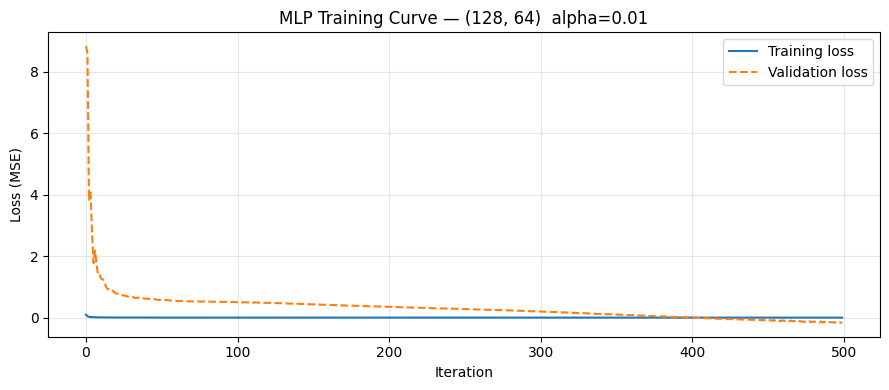

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_model.loss_curve_, linewidth=1.5, label='Training loss')
if hasattr(best_model, 'validation_scores_') and best_model.validation_scores_ is not None:
    # validation_scores_ is negative MSE when early_stopping=True
    val_loss = [-s for s in best_model.validation_scores_]
    ax.plot(val_loss, linewidth=1.5, linestyle='--', label='Validation loss')
ax.set(xlabel='Iteration', ylabel='Loss (MSE)',
       title=f'MLP Training Curve — {best["layers"]}  alpha={best["alpha"]}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Portfolio Formation & Sharpe Ratio

NEURAL NETWORK LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 3.5141%
  Std monthly    : 7.0220%
  Sharpe (ann.)  : 1.7336


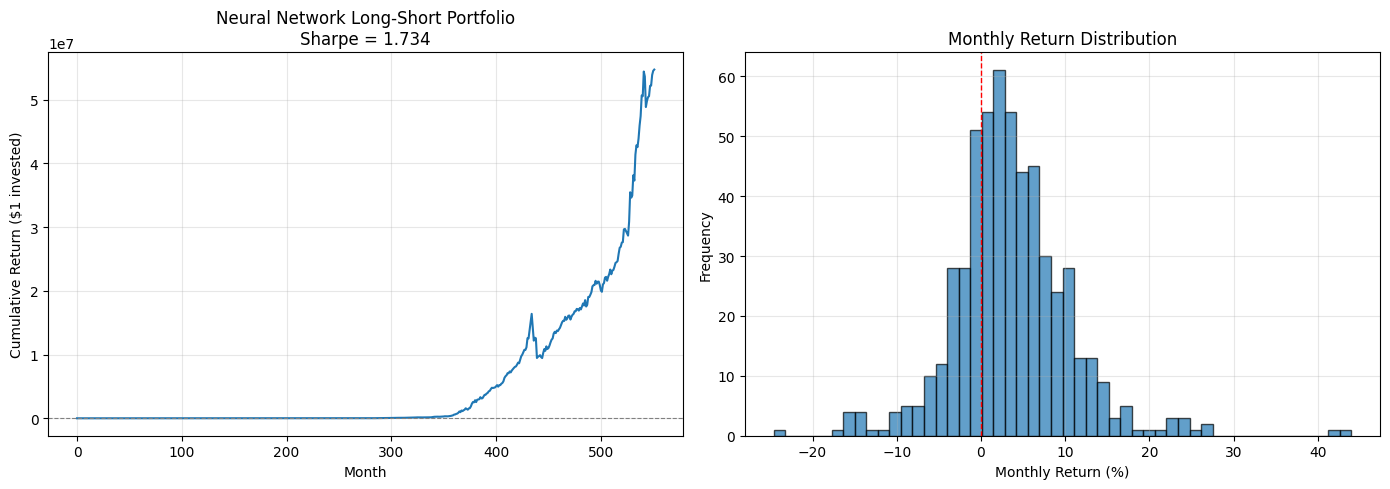

In [8]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('NEURAL NETWORK LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'Neural Network Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7 — Save Results

In [9]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'Neural Network',
        description   = f'MLPRegressor — ReLU activations, Adam optimizer, early stopping',
        tuning_params = (f"layers={best['layers']}, alpha={best['alpha']}, "
                         f"activation={CONFIG['ACTIVATION']}, n_iter={best['n_iter']}"),
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'neural_network',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'nn_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'nn_portfolios.csv')
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/nn_summary.csv


Saved: results/nn_portfolios.csv
